# 04 — Model Training and Evaluation

This notebook trains and evaluates exactly three machine learning models for the Idealista Investment Opportunity Detector project.

Main goals:
- Load the model-ready dataset from `data/processed/`
- Define the supervised regression problem
- Define the target variable and input features
- Split the dataset into train and test sets
- Build preprocessing pipelines for numerical and categorical features
- Train exactly three models
- Evaluate models using MAE, RMSE and R²
- Select and save the best model
- Export predictions and metrics for later visualization and Streamlit usage


## 1. Imports and project paths


In [1]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data dir:", PROCESSED_DATA_DIR.resolve())
print("Models dir:", MODELS_DIR.resolve())


Project root: C:\Users\hugol\Desktop\Python\B2\ml-poc-project
Processed data dir: C:\Users\hugol\Desktop\Python\B2\ml-poc-project\data\processed
Models dir: C:\Users\hugol\Desktop\Python\B2\ml-poc-project\models


## 2. Load model-ready dataset

The expected input file is:

```text
data/processed/idealista_model_ready_latest.csv
```


In [2]:
MODEL_READY_PATH = PROCESSED_DATA_DIR / "idealista_model_ready_latest.csv"

if not MODEL_READY_PATH.exists():
    raise FileNotFoundError(
        f"Model-ready dataset not found at {MODEL_READY_PATH}. "
        "Run notebooks/03_feature_engineering.ipynb first."
    )

df = pd.read_csv(MODEL_READY_PATH)

print("Dataset loaded:", MODEL_READY_PATH)
print("Shape:", df.shape)
display(df.head())


Dataset loaded: ..\data\processed\idealista_model_ready_latest.csv
Shape: (489, 35)


,price,size,rooms,bathrooms,latitude,longitude,distance,numPhotos,floor_numeric,rooms_per_100m2,bathrooms_per_room,log_size,log_num_photos,description_length,has_lift,has_lift_missing,is_exterior,is_exterior_missing,has_parking,has_parking_missing,parking_included,parking_included_missing,new_development_finished,new_development_finished_missing,has_price_drop,has_luxury_keywords,has_renovation_keywords,has_investment_keywords,floor_missing,propertyType,district,neighborhood,municipality,detailedType_typology,detailedType_subTypology
0,"3,950,000.00",603.00,7,7,40.43,-3.78,6587,62,3.00,1.16,1.00,6.40,4.14,2967,0,1,0,1,1,0,1,0,0,1,0,1,0,0,1,chalet,Somosaguas,Somosaguas,Pozuelo de Alarcón,chalet,independantHouse
1,"1,400,000.00",177.00,2,2,40.42,-3.71,617,46,6.00,1.13,1.00,5.18,3.85,2496,1,0,1,0,0,1,0,1,0,1,1,1,1,0,0,penthouse,Centro,Palacio,Madrid,flat,penthouse
2,"3,800,000.00","1,000.00",7,6,40.43,-3.79,7775,71,3.00,0.70,0.86,6.91,4.28,1746,0,1,0,1,1,0,1,0,0,1,1,1,0,0,1,chalet,Somosaguas,Somosaguas,Pozuelo de Alarcón,chalet,independantHouse
3,"2,100,000.00",137.00,3,3,40.42,-3.68,2404,33,3.00,2.19,1.00,4.93,3.53,1272,1,0,1,0,0,1,0,1,0,1,1,1,0,0,0,flat,Barrio de Salamanca,Goya,Madrid,flat,Unknown
4,"4,950,000.00",383.00,5,3,40.43,-3.68,2523,51,6.00,1.31,0.60,5.95,3.95,2018,1,0,1,0,0,1,0,1,0,1,0,1,0,0,0,flat,Barrio de Salamanca,Castellana,Madrid,flat,Unknown


## 3. Define the ML problem

This is a **supervised regression** problem.

Target variable:

```text
price
```

The model predicts the listing price of a property based on its characteristics.


In [3]:
target_col = "price"

if target_col not in df.columns:
    raise ValueError(f"Target column {target_col!r} not found in dataset.")

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(y.describe())


X shape: (489, 34)
y shape: (489,)


count         489.00
mean    2,096,452.76
std     1,459,007.62
min       300,000.00
25%     1,020,000.00
50%     1,675,900.00
75%     2,675,000.00
max     8,900,000.00
Name: price, dtype: float64

## 4. Feature types

Numerical and categorical variables are handled differently:
- Numerical features: median imputation + scaling
- Categorical features: most frequent imputation + one-hot encoding


In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)


Number of numerical features: 28
['size', 'rooms', 'bathrooms', 'latitude', 'longitude', 'distance', 'numPhotos', 'floor_numeric', 'rooms_per_100m2', 'bathrooms_per_room', 'log_size', 'log_num_photos', 'description_length', 'has_lift', 'has_lift_missing', 'is_exterior', 'is_exterior_missing', 'has_parking', 'has_parking_missing', 'parking_included', 'parking_included_missing', 'new_development_finished', 'new_development_finished_missing', 'has_price_drop', 'has_luxury_keywords', 'has_renovation_keywords', 'has_investment_keywords', 'floor_missing']

Number of categorical features: 6
['propertyType', 'district', 'neighborhood', 'municipality', 'detailedType_typology', 'detailedType_subTypology']


## 5. Train/test split

The dataset is split into:
- 80% training data
- 20% test data

The test set is held out and used only for final evaluation.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target median:", y_train.median())
print("Test target median:", y_test.median())


Train shape: (391, 34)
Test shape: (98, 34)
Train target median: 1795000.0
Test target median: 1492500.0


## 6. Preprocessing pipeline


In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")


Preprocessor created.


## 7. Define exactly three models

The assignment requires exactly three models.

Selected models:

1. **Ridge Regression** — linear baseline model with L2 regularization.
2. **Random Forest Regressor** — non-linear ensemble model based on decision trees.
3. **Gradient Boosting Regressor** — sequential ensemble model that often performs well on tabular data.


In [7]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    for name, model in models.items()
}

print("Models defined:")
for name in pipelines:
    print("-", name)


Models defined:
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor


## 8. Cross-validation protocol

We use 5-fold cross-validation on the training set.

Metrics:
- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- R²: coefficient of determination

The main metric is **MAE** because it is easy to interpret in euros.


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_results = []

for name, pipeline in pipelines.items():
    print(f"Running cross-validation for: {name}")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "model": name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae_mean")
display(cv_results_df)


Running cross-validation for: Ridge Regression
Running cross-validation for: Random Forest Regressor
Running cross-validation for: Gradient Boosting Regressor


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
2,Gradient Boosting Regressor,"384,269.71","14,423.46","629,174.18","68,638.78",0.79,0.02
1,Random Forest Regressor,"428,286.26","18,056.96","692,838.55","90,626.75",0.75,0.03
0,Ridge Regression,"471,111.91","26,423.95","672,660.33","56,268.29",0.76,0.02


## 9. Train final models and evaluate on test set


In [25]:
test_results = []
trained_pipelines = {}
predictions = {}

for name, pipeline in pipelines.items():
    print(f"Training final model: {name}")

    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    test_results.append({
        "model": name,
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2
    })

test_results_df = pd.DataFrame(test_results).sort_values("test_mae")
display(test_results_df)


Training final model: Ridge Regression
Training final model: Random Forest Regressor
Training final model: Gradient Boosting Regressor


,model,test_mae,test_rmse,test_r2
2,Gradient Boosting Regressor,"462,609.49","690,149.48",0.82
1,Random Forest Regressor,"498,647.59","785,570.19",0.77
0,Ridge Regression,"525,458.88","841,349.53",0.73


## 10. Combine CV and test results


In [26]:
metrics_df = (
    cv_results_df
    .merge(test_results_df, on="model", how="left")
    .sort_values("test_mae")
)

display(metrics_df)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

metrics_path = REPORTS_DIR / f"model_metrics_{timestamp}.csv"
latest_metrics_path = REPORTS_DIR / "model_metrics_latest.csv"

metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
metrics_df.to_csv(latest_metrics_path, index=False, encoding="utf-8-sig")

print("Saved metrics:", metrics_path)
print("Saved latest metrics:", latest_metrics_path)


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_mae,test_rmse,test_r2
0,Gradient Boosting Regressor,"384,269.71","14,423.46","629,174.18","68,638.78",0.79,0.02,"462,609.49","690,149.48",0.82
1,Random Forest Regressor,"428,286.26","18,056.96","692,838.55","90,626.75",0.75,0.03,"498,647.59","785,570.19",0.77
2,Ridge Regression,"471,111.91","26,423.95","672,660.33","56,268.29",0.76,0.02,"525,458.88","841,349.53",0.73


Saved metrics: ..\reports\model_metrics_20260506_150158.csv
Saved latest metrics: ..\reports\model_metrics_latest.csv


## 11. Select best model


In [28]:
best_model_name = metrics_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)
print("Best test MAE:", metrics_df.iloc[0]["test_mae"])
print("Best test RMSE:", metrics_df.iloc[0]["test_rmse"])
print("Best test R²:", metrics_df.iloc[0]["test_r2"])


Best model: Gradient Boosting Regressor
Best test MAE: 462609.49387603
Best test RMSE: 690149.4839031997
Best test R²: 0.8201945822664145


## 12. Save best model


In [29]:
best_model_path = MODELS_DIR / f"best_model_{timestamp}.pkl"
latest_best_model_path = MODELS_DIR / "best_model_latest.pkl"

joblib.dump(best_pipeline, best_model_path)
joblib.dump(best_pipeline, latest_best_model_path)

print("Saved best model:", best_model_path)
print("Saved latest best model:", latest_best_model_path)


Saved best model: ..\models\best_model_20260506_150158.pkl
Saved latest best model: ..\models\best_model_latest.pkl


## 13. Save predictions

The prediction file is useful for Assignment 4 visualizations, the Streamlit app, and investment opportunity scoring.


In [30]:
predictions_df = X_test.copy()
predictions_df["actual_price"] = y_test.values
predictions_df["predicted_price"] = best_predictions
predictions_df["prediction_error"] = predictions_df["predicted_price"] - predictions_df["actual_price"]
predictions_df["absolute_error"] = np.abs(predictions_df["prediction_error"])
predictions_df["percentage_error"] = (
    predictions_df["prediction_error"] / predictions_df["actual_price"] * 100
)

predictions_df["valuation_status"] = np.select(
    [
        predictions_df["percentage_error"] >= 10,
        predictions_df["percentage_error"] <= -10
    ],
    [
        "potentially_undervalued",
        "potentially_overvalued"
    ],
    default="fairly_priced"
)

predictions_path = PROCESSED_DATA_DIR / f"model_predictions_{timestamp}.csv"
latest_predictions_path = PROCESSED_DATA_DIR / "model_predictions_latest.csv"

predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
predictions_df.to_csv(latest_predictions_path, index=False, encoding="utf-8-sig")

print("Saved predictions:", predictions_path)
print("Saved latest predictions:", latest_predictions_path)
display(predictions_df.head())


Saved predictions: ..\data\processed\model_predictions_20260506_150158.csv
Saved latest predictions: ..\data\processed\model_predictions_latest.csv


,size,rooms,bathrooms,latitude,longitude,distance,numPhotos,floor_numeric,rooms_per_100m2,bathrooms_per_room,log_size,log_num_photos,description_length,has_lift,has_lift_missing,is_exterior,is_exterior_missing,has_parking,has_parking_missing,parking_included,parking_included_missing,new_development_finished,new_development_finished_missing,has_price_drop,has_luxury_keywords,has_renovation_keywords,has_investment_keywords,floor_missing,propertyType,district,neighborhood,municipality,detailedType_typology,detailedType_subTypology,actual_price,predicted_price,prediction_error,absolute_error,percentage_error,valuation_status
451,101.00,2,2,40.42,-3.68,2130,28,2.00,1.98,1.00,4.62,3.37,1218,1,0,1,0,0,1,0,1,0,1,0,1,1,0,0,flat,Retiro,Ibiza,Madrid,flat,Unknown,"1,375,000.00","1,099,587.62","-275,412.38","275,412.38",-20.03,potentially_overvalued
84,241.00,4,5,40.44,-3.69,2547,32,2.00,1.66,1.25,5.49,3.50,2169,1,0,1,0,0,1,0,1,0,1,0,1,1,0,0,flat,Barrio de Salamanca,Castellana,Madrid,flat,Unknown,"2,780,000.00","3,103,542.43","323,542.43","323,542.43",11.64,potentially_undervalued
434,113.00,3,3,40.43,-3.68,2538,23,5.00,2.65,1.00,4.74,3.18,1567,1,0,1,0,0,1,0,1,0,1,0,1,1,1,0,flat,Barrio de Salamanca,Goya,Madrid,flat,Unknown,"1,495,000.00","1,349,452.35","-145,547.65","145,547.65",-9.74,fairly_priced
472,162.00,1,2,40.51,-3.66,10728,19,1.00,0.62,2.00,5.09,3.00,1512,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,duplex,Hortaleza,Sanchinarro,Madrid,flat,duplex,"750,000.00","1,334,215.12","584,215.12","584,215.12",77.90,potentially_undervalued
428,180.00,3,4,40.46,-3.69,5079,90,9.00,1.67,1.33,5.20,4.51,2117,1,0,1,0,0,1,0,1,0,1,1,1,1,0,0,flat,Tetuán,Cuzco-Castillejos,Madrid,flat,Unknown,"1,425,000.00","1,925,151.44","500,151.44","500,151.44",35.10,potentially_undervalued


## 14. Model performance visualizations


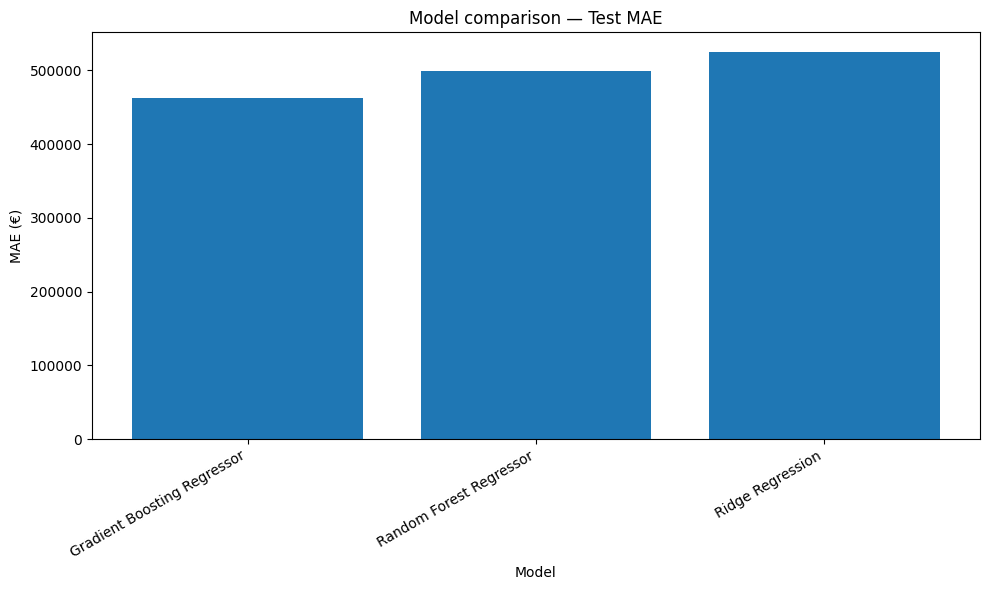

Saved figure: ..\reports\figures\model_comparison_mae_20260506_150158.png


In [31]:
plt.figure(figsize=(10, 6))
plt.bar(metrics_df["model"], metrics_df["test_mae"])
plt.title("Model comparison — Test MAE")
plt.xlabel("Model")
plt.ylabel("MAE (€)")
plt.xticks(rotation=30, ha="right")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

mae_fig_path = FIGURES_DIR / f"model_comparison_mae_{timestamp}.png"
plt.savefig(mae_fig_path, dpi=150)
plt.show()

print("Saved figure:", mae_fig_path)


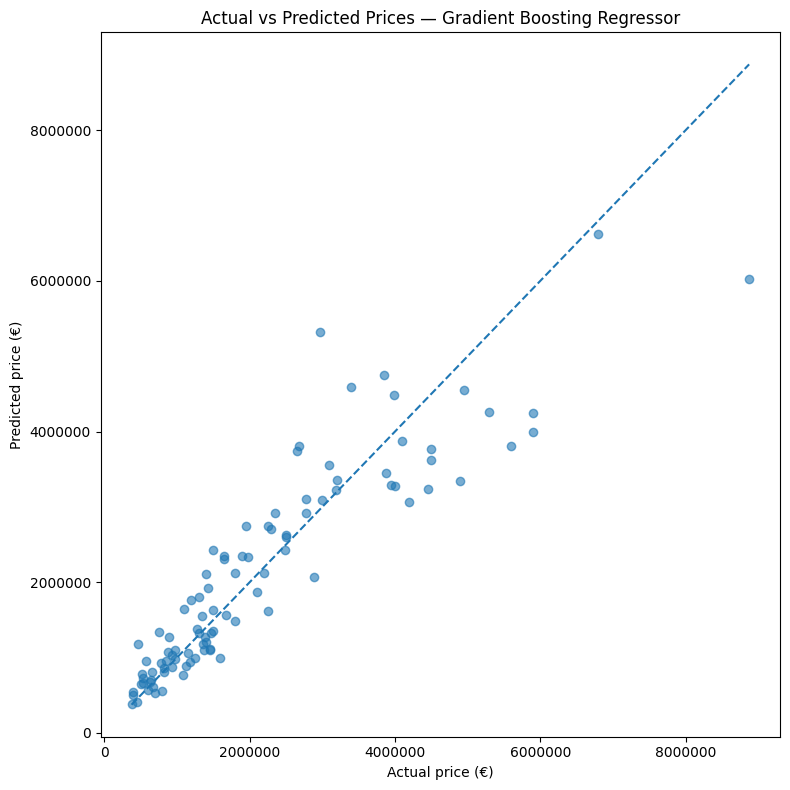

Saved figure: ..\reports\figures\actual_vs_predicted_20260506_150158.png


In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(predictions_df["actual_price"], predictions_df["predicted_price"], alpha=0.6)

min_price = min(predictions_df["actual_price"].min(), predictions_df["predicted_price"].min())
max_price = max(predictions_df["actual_price"].max(), predictions_df["predicted_price"].max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
plt.title(f"Actual vs Predicted Prices — {best_model_name}")
plt.xlabel("Actual price (€)")
plt.ylabel("Predicted price (€)")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()

actual_vs_pred_fig_path = FIGURES_DIR / f"actual_vs_predicted_{timestamp}.png"
plt.savefig(actual_vs_pred_fig_path, dpi=150)
plt.show()

print("Saved figure:", actual_vs_pred_fig_path)


## 15. Feature importance for tree-based best models


,feature,importance
0,size,0.35
10,log_size,0.28
5,distance,0.06
35,district_Barrio de Salamanca,0.05
4,longitude,0.05
2,bathrooms,0.04
8,rooms_per_100m2,0.04
11,log_num_photos,0.02
6,numPhotos,0.02
103,neighborhood_Recoletos,0.02


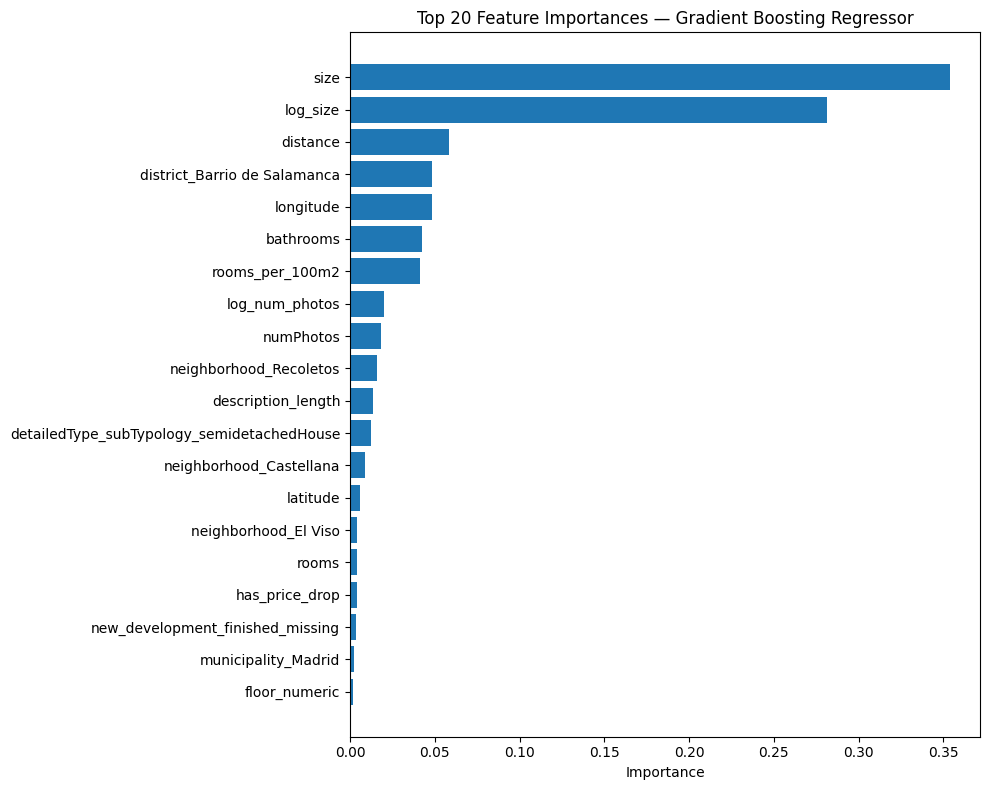

Saved figure: ..\reports\figures\feature_importance_20260506_150158.png


In [33]:
def get_feature_names(preprocessor, numeric_features, categorical_features):
    feature_names = []
    feature_names.extend(numeric_features)

    if categorical_features:
        onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

    return feature_names

fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]

if hasattr(fitted_model, "feature_importances_"):
    feature_names = get_feature_names(fitted_preprocessor, numeric_features, categorical_features)
    importances = fitted_model.feature_importances_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
    )

    display(importance_df.head(30))

    plt.figure(figsize=(10, 8))
    top_importance = importance_df.head(20).sort_values("importance")
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()

    importance_fig_path = FIGURES_DIR / f"feature_importance_{timestamp}.png"
    plt.savefig(importance_fig_path, dpi=150)
    plt.show()

    print("Saved figure:", importance_fig_path)
else:
    print(f"{best_model_name} does not expose feature_importances_.")


## 16. Save modeling metadata


In [34]:
metadata = {
    "created_at": timestamp,
    "dataset_path": str(MODEL_READY_PATH),
    "dataset_shape": [int(df.shape[0]), int(df.shape[1])],
    "target_col": target_col,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "models": list(models.keys()),
    "evaluation_protocol": {
        "train_test_split": "80/20",
        "random_state": RANDOM_STATE,
        "cross_validation": "5-fold KFold on training set",
        "main_metric": "MAE",
        "secondary_metrics": ["RMSE", "R2"]
    },
    "best_model": best_model_name,
    "best_model_path": str(latest_best_model_path),
    "metrics_path": str(latest_metrics_path),
    "predictions_path": str(latest_predictions_path)
}

metadata_path = REPORTS_DIR / f"model_training_metadata_{timestamp}.json"
latest_metadata_path = REPORTS_DIR / "model_training_metadata_latest.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

with open(latest_metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved metadata:", metadata_path)
print("Saved latest metadata:", latest_metadata_path)


Saved metadata: ..\reports\model_training_metadata_20260506_150158.json
Saved latest metadata: ..\reports\model_training_metadata_latest.json


## 17. Assignment 3 report cells


In [36]:
print("=== ASSIGNMENT 3 REPORT — PART 1: PROBLEM DEFINITION ===")
print("Problem type: Supervised regression")
print(f"Target variable: {target_col}")
print(f"Dataset shape: {df.shape}")
print(f"Number of input features: {X.shape[1]}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print("Train/test split: 80/20")
print("Cross-validation: 5-fold KFold on training set")
print("Main metric: MAE")
print("Secondary metrics: RMSE, R²")


=== ASSIGNMENT 3 REPORT — PART 1: PROBLEM DEFINITION ===
Problem type: Supervised regression
Target variable: price
Dataset shape: (489, 35)
Number of input features: 34
Train shape: (391, 34)
Test shape: (98, 34)
Train/test split: 80/20
Cross-validation: 5-fold KFold on training set
Main metric: MAE
Secondary metrics: RMSE, R²


In [37]:
print("=== ASSIGNMENT 3 REPORT — PART 2: MODELS SELECTED ===")
for model_name in models.keys():
    print("-", model_name)


=== ASSIGNMENT 3 REPORT — PART 2: MODELS SELECTED ===
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor


In [38]:
print("=== ASSIGNMENT 3 REPORT — PART 3: CROSS-VALIDATION RESULTS ===")
print(cv_results_df.to_string(index=False))


=== ASSIGNMENT 3 REPORT — PART 3: CROSS-VALIDATION RESULTS ===
                      model  cv_mae_mean  cv_mae_std  cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std
Gradient Boosting Regressor   384,269.71   14,423.46    629,174.18    68,638.78        0.79       0.02
    Random Forest Regressor   428,286.26   18,056.96    692,838.55    90,626.75        0.75       0.03
           Ridge Regression   471,111.91   26,423.95    672,660.33    56,268.29        0.76       0.02


In [22]:
print("=== ASSIGNMENT 3 REPORT — PART 4: TEST RESULTS ===")
print(test_results_df.to_string(index=False))


=== ASSIGNMENT 3 REPORT — PART 4: TEST RESULTS ===
                      model   test_mae          test_rmse  test_r2
Gradient Boosting Regressor 462,609.49 476,306,310,131.85     0.82
    Random Forest Regressor 498,647.59 617,120,518,931.99     0.77
           Ridge Regression 525,458.88 707,869,036,271.44     0.73


In [23]:
print("=== ASSIGNMENT 3 REPORT — PART 5: BEST MODEL ===")
print(f"Best model: {best_model_name}")
print(f"Best model test MAE: {metrics_df.iloc[0]['test_mae']:,.2f}")
print(f"Best model test RMSE: {metrics_df.iloc[0]['test_rmse']:,.2f}")
print(f"Best model test R²: {metrics_df.iloc[0]['test_r2']:,.4f}")


=== ASSIGNMENT 3 REPORT — PART 5: BEST MODEL ===
Best model: Gradient Boosting Regressor
Best model test MAE: 462,609.49
Best model test RMSE: 476,306,310,131.85
Best model test R²: 0.8202


In [24]:
print("=== ASSIGNMENT 3 REPORT — PART 6: OUTPUT FILES ===")
print("Best model:", latest_best_model_path)
print("Metrics:", latest_metrics_path)
print("Predictions:", latest_predictions_path)
print("Metadata:", latest_metadata_path)


=== ASSIGNMENT 3 REPORT — PART 6: OUTPUT FILES ===
Best model: ..\models\best_model_latest.pkl
Metrics: ..\reports\model_metrics_latest.csv
Predictions: ..\data\processed\model_predictions_latest.csv
Metadata: ..\reports\model_training_metadata_latest.json
